In [1]:
import pandas as pd
import os
import json
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis, FeaturePredictiveEvaluator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [3]:
# Enable automatic reloading of modules before executing user code (useful during development)
%load_ext autoreload
%autoreload 2

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
PARQUET_PATH = os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars.parquet")
JSON_METADATA_PATH =os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars_metadata.json")

In [5]:
# Load dataframe
df = pd.read_parquet(PARQUET_PATH)
df.head()

,iso_alpha_3,year,country_name,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,...,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
0,AFG,2002,Afghanistan,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AFG,2003,Afghanistan,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AFG,2004,Afghanistan,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AFG,2005,Afghanistan,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,Afghanistan,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 71 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   iso_alpha_3                                2856 non-null   object 
 1   year                                       2856 non-null   int64  
 2   country_name                               2856 non-null   object 
 3   cap_gdp_current_usd                        2856 non-null   float64
 4   cap_gdp_per_capita_constant_2015           2856 non-null   float64
 5   cap_gdp_per_capita_ppp_current             2856 non-null   float64
 6   cap_population                             2856 non-null   float64
 7   cap_electoral_democracy_idx                2856 non-null   float64
 8   cap_liberal_democracy_idx                  2856 non-null   float64
 9   cap_corruption_idx                         2856 non-null   float64
 10  cap_rule_of_law_idx     

In [7]:
# Load metadata
with open(JSON_METADATA_PATH, "r") as file:
    df_metadata = json.load(file) 
df_metadata.keys()

dict_keys(['configuration', 'dimensions', 'zero_filled_variables'])

In [8]:
# Obtain emission fields
emission_fields = df_metadata["dimensions"]["EMISSIONS"]
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_mt',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [9]:
df[emission_fields]

,con_co2_incl_luc_mt,con_co2_intensity,con_co2_mt,con_co2_per_capita,con_edgar_ghg_mt,con_edgar_ghg_gg,con_ghg_per_capita,con_methane_mt,con_nitrous_oxide_mt,con_share_global_co2_pct,con_total_emissions,con_total_ghg_mt
0,6.391,169.01,1.341,0.063,17.044710,17044.710352,0.937,10.375,3.299,0.005,0.12,20.037
1,6.169,241.76,1.560,0.069,17.732318,17732.317739,0.914,10.687,3.434,0.006,0.22,20.769
2,3.636,227.85,1.237,0.053,17.789451,17789.451447,0.804,10.651,3.412,0.004,0.18,18.934
3,2.983,219.51,1.890,0.077,18.191324,18191.324358,0.787,10.901,3.561,0.006,0.18,19.199
4,3.244,255.56,2.159,0.085,18.461036,18461.036258,0.764,11.122,3.418,0.007,0.23,19.426
...,...,...,...,...,...,...,...,...,...,...,...,...
2851,10.131,395.55,11.209,0.746,31.273375,31273.374543,1.813,11.831,5.206,0.031,3.73,27.250
2852,16.597,429.25,10.267,0.672,30.207339,30207.339246,2.008,11.636,5.099,0.028,3.64,30.672
2853,7.897,371.09,8.491,0.547,28.341567,28341.566541,1.555,11.314,4.591,0.024,2.49,24.146
2854,12.444,269.55,10.223,0.647,29.525357,29525.356700,1.767,11.840,4.858,0.028,2.31,27.907


In [10]:
# define target variable
target_var = "con_edgar_ghg_mt"

## Data prep

### Filter data to avoid leakage

In [11]:
emission_fields.remove(target_var)
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [12]:
df_filtered = df.drop(columns=emission_fields + ["country_name"])
df_filtered.columns

Index(['iso_alpha_3', 'year', 'cap_gdp_current_usd',
       'cap_gdp_per_capita_constant_2015', 'cap_gdp_per_capita_ppp_current',
       'cap_population', 'cap_electoral_democracy_idx',
       'cap_liberal_democracy_idx', 'cap_corruption_idx',
       'cap_rule_of_law_idx', 'cap_accountability_idx',
       'cap_civil_liberties_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_bioenergy', 'con_coal', 'con_demand',
       'con_demand_per_capita', 'con_electricity_access_pct',
       'con_electricity_generation_twh', 'con_energy_per_capita_kwh',
       'con_forest_area_pct', 'con_fossil_share_elec_pct', 'con_gas',
       'con_gas_and_other_fossil', 'con_hydro',
       'con_hydro,_bioenergy_and_other_renewables', 'con_net_elec_imports_twh',
       'con_nuclear', 'con_other_fossil', 'con_population',
       'con_primary_energy_twh'

### Filter some redoundant variables

In [13]:
redoundant_fields = [
    "cap_gdp_per_capita_ppp_current",
    "con_population"
]

In [14]:
df_filtered = df_filtered.drop(columns=redoundant_fields)

### Check for correlation between features

In [15]:
X = df_filtered.drop(columns=["iso_alpha_3", "year", target_var])

In [16]:
def get_corr_pairs_df(df, corr_thr=0.9):

    features_corr = df.corr().abs()
    pairs = []

    for i in range(len(features_corr.columns)):
        for j in range(i+1, len(features_corr.columns)):
            if abs(features_corr.iloc[i, j]) > corr_thr:
                pairs.append(
                    (features_corr.columns[i],
                    features_corr.columns[j],
                    features_corr.iloc[i, j])
                )

    pairs_df = pd.DataFrame(pairs, columns=["feat_1","feat_2","corr"])
    return pairs_df

In [17]:
pairs_df = get_corr_pairs_df(X)
pairs_df.head()

,feat_1,feat_2,corr
0,cap_gdp_current_usd,con_gas_and_other_fossil,0.901349
1,cap_electoral_democracy_idx,cap_liberal_democracy_idx,0.976441
2,cap_electoral_democracy_idx,cap_accountability_idx,0.955689
3,cap_electoral_democracy_idx,cap_civil_liberties_idx,0.902647
4,cap_electoral_democracy_idx,cap_voice_accountability,0.944279


In [18]:
# pairs_df.to_clipboard(index=False)

In [19]:
to_drop = [
   "cap_accountability_idx",
   "cap_voice_accountability",
   "cap_control_corruption",
   "cap_rule_of_law",
   "cap_rule_of_law_idx",
   "cap_electoral_democracy_idx",
   "cap_accountability_idx",
   "con_gas_and_other_fossil",
   "cap_regulatory_quality",
   "con_demand",
   "con_coal",
   "con_electricity_generation_twh",
   "con_total_generation",
   "con_renewables_share_elec_pct",
   "con_gas_and_other_fossil",
   "con_hydro,_bioenergy_and_other_renewables",
   "con_ndgain_score",
   "con_solar",
   "inc_has_ets"
]

print(f"Dropping {len(to_drop)} variables")
print("Shape before dropping: ", df_filtered.shape)
df_filtered = df_filtered.drop(columns=to_drop)
print("Shape after dropping: ", df_filtered.shape)


Dropping 19 variables
Shape before dropping:  (2856, 57)
Shape after dropping:  (2856, 40)


In [20]:
X = df_filtered.drop(columns=["iso_alpha_3", "year", target_var])
pairs_df_after_drop = get_corr_pairs_df(X)
pairs_df_after_drop

,feat_1,feat_2,corr


### Fix Skewness

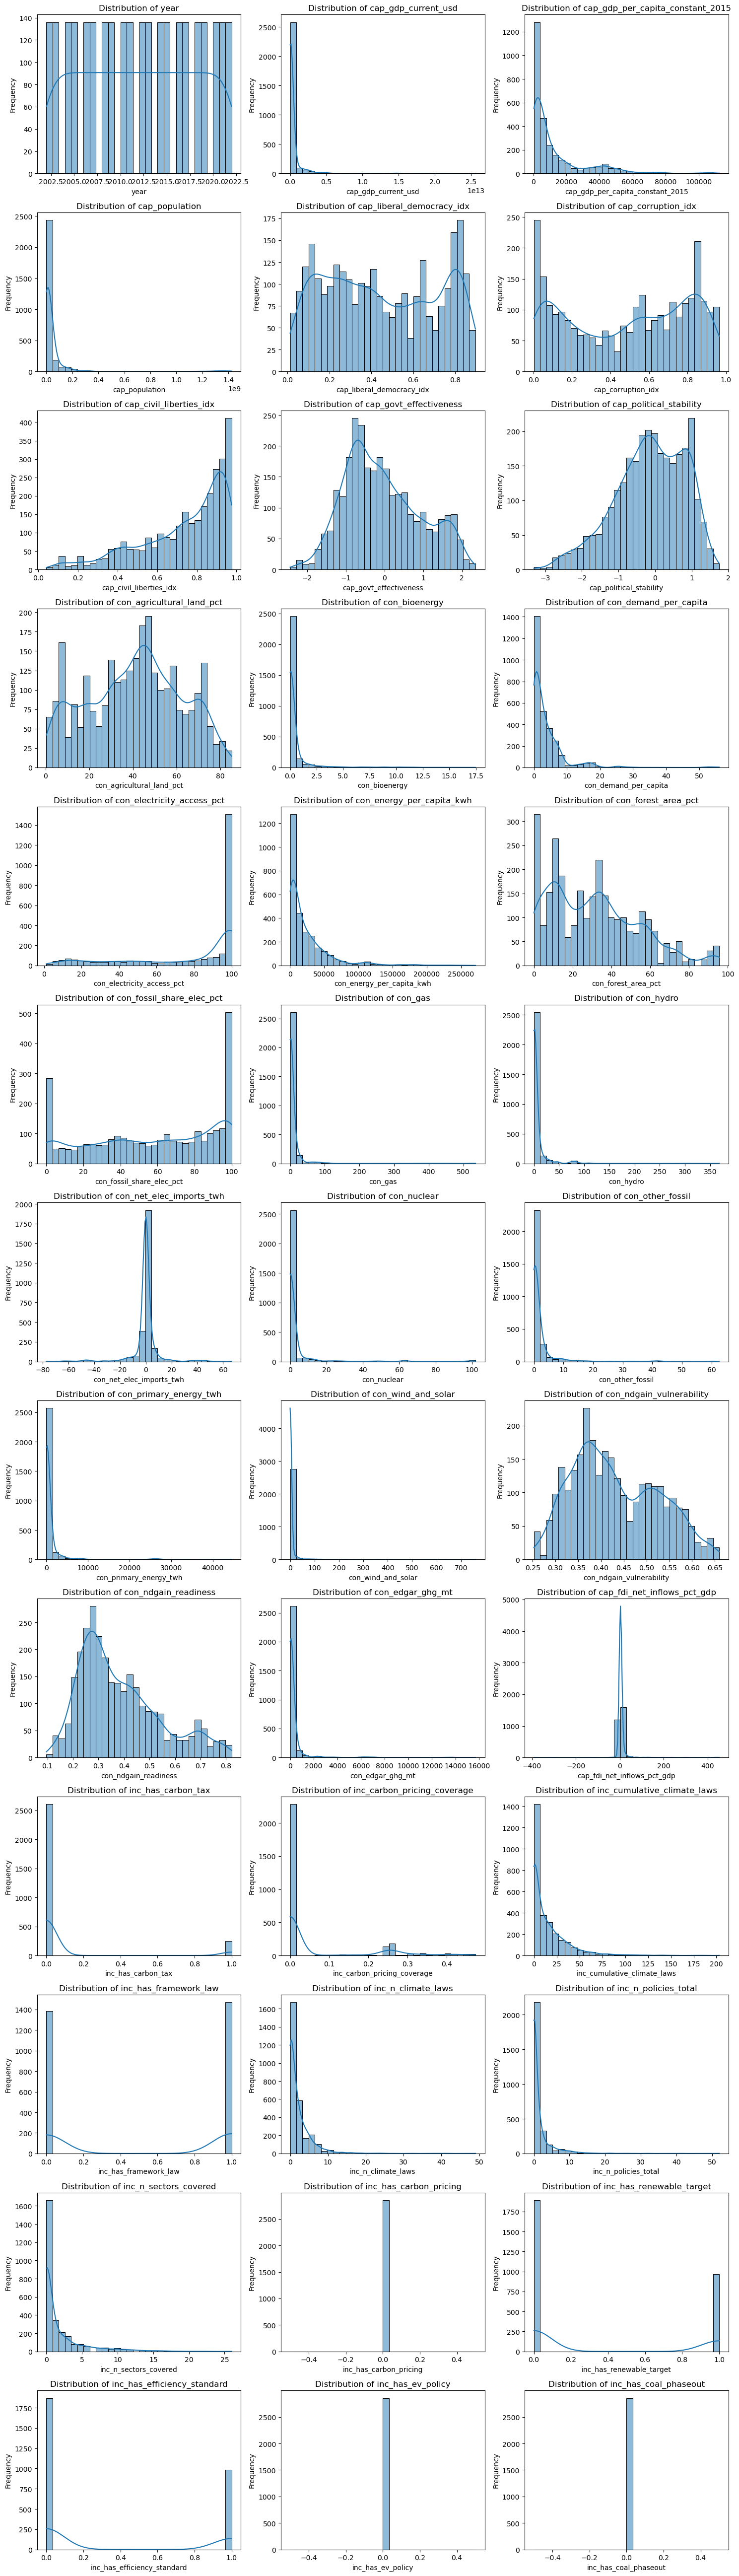

In [21]:
eda_utils.plot_numeric_fields_distributions(df_filtered)

In [22]:
df_filtered.describe()

,year,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_population,cap_liberal_democracy_idx,cap_corruption_idx,cap_civil_liberties_idx,cap_govt_effectiveness,cap_political_stability,con_agricultural_land_pct,...,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
count,2856.000000,2.856000e+03,2856.000000,2.856000e+03,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,...,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.0,2856.000000,2856.000000,2856.0,2856.0
mean,2012.000000,4.549098e+11,12569.581328,4.474379e+07,0.447432,0.487975,0.735454,-0.058090,-0.148709,41.041622,...,14.716737,0.515406,2.184174,1.440476,1.761204,0.0,0.337535,0.345588,0.0,0.0
std,6.056361,1.823163e+12,17858.950458,1.618958e+08,0.262918,0.313468,0.218340,0.974984,0.951577,21.219409,...,21.349578,0.499850,3.496865,3.233141,3.296187,0.0,0.472952,0.475643,0.0,0.0
min,2002.000000,8.517107e+07,243.076666,8.247500e+04,0.012000,0.002000,0.041000,-2.440229,-3.312951,0.436116,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
25%,2007.000000,1.017460e+10,1380.254844,3.263544e+06,0.217000,0.170000,0.608000,-0.784158,-0.749497,24.892560,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
50%,2012.000000,3.302481e+10,4789.834002,9.695688e+06,0.421000,0.532000,0.806000,-0.200911,-0.087762,42.739012,...,7.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
75%,2017.000000,1.894862e+11,15053.013707,2.838703e+07,0.688000,0.784000,0.913000,0.596476,0.625529,57.373975,...,22.000000,1.000000,3.000000,1.000000,2.000000,0.0,1.000000,1.000000,0.0,0.0
max,2022.000000,2.560485e+13,112417.876989,1.425423e+09,0.897000,0.965000,0.976000,2.347191,1.753184,85.287396,...,203.000000,1.000000,49.000000,52.000000,26.000000,0.0,1.000000,1.000000,0.0,0.0


In [23]:
# Identify full o zeros and drop them
zero_cols = df_filtered.columns[(df_filtered == 0).all()]
df_filtered = df_filtered.drop(columns=zero_cols)
print(zero_cols)


Index(['inc_has_carbon_pricing', 'inc_has_ev_policy', 'inc_has_coal_phaseout'], dtype='object')


In [24]:
# Identify binary columns
binary_cols = [
    c for c in df_filtered.columns
    if df_filtered[c].nunique(dropna=True) == 2
]
binary_cols

['inc_has_carbon_tax',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard']

In [25]:
# Identify columns with low variance and with a lot of zeros

def get_zeros_and_variance_check_df(df):
    zeros_and_variance_check = []
    for field in df.select_dtypes(np.number):
        zero_share = (df[field] == 0).mean()
        field_var = df[field].var()

        if field in binary_cols:
            binary_flag = True
        else:
            binary_flag = False


        zeros_and_variance_check.append((field, zero_share, field_var, binary_flag))

    zeros_and_variance_check_df = pd.DataFrame(data=zeros_and_variance_check, columns=["field_name", "field_zero_share", "field_variance", "bianry_flag"])
    return zeros_and_variance_check_df

In [26]:
zeros_and_variance_check_df = get_zeros_and_variance_check_df(df_filtered)

In [27]:
# zeros_and_variance_check_df.to_clipboard(index=False)

In [28]:
skew = df_filtered[[col for col in df_filtered.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew.head(20)

con_wind_and_solar                  16.703063
con_gas                             10.058157
con_hydro                            8.669590
cap_fdi_net_inflows_pct_gdp          8.480725
con_edgar_ghg_mt                     8.467774
cap_gdp_current_usd                  8.097445
con_primary_energy_twh               7.524785
cap_population                       7.233621
con_nuclear                          6.399152
con_other_fossil                     6.160889
con_bioenergy                        5.676543
inc_n_policies_total                 5.154487
con_demand_per_capita                4.576735
inc_n_climate_laws                   4.486000
con_energy_per_capita_kwh            2.979298
inc_cumulative_climate_laws          2.726220
inc_n_sectors_covered                2.685346
cap_gdp_per_capita_constant_2015     2.322028
inc_carbon_pricing_coverage          1.845223
con_ndgain_readiness                 0.853076
dtype: float64

In [29]:
skew.tail(10)

con_ndgain_vulnerability      0.346669
cap_liberal_democracy_idx     0.100043
year                          0.000000
con_agricultural_land_pct    -0.079755
cap_corruption_idx           -0.148069
con_fossil_share_elec_pct    -0.295079
cap_political_stability      -0.516479
con_net_elec_imports_twh     -0.981781
cap_civil_liberties_idx      -1.038481
con_electricity_access_pct   -1.156544
dtype: float64

In [30]:
highly_skewed_fields = skew[skew.abs() >= 1].index.to_list()
highly_skewed_fields

['con_wind_and_solar',
 'con_gas',
 'con_hydro',
 'cap_fdi_net_inflows_pct_gdp',
 'con_edgar_ghg_mt',
 'cap_gdp_current_usd',
 'con_primary_energy_twh',
 'cap_population',
 'con_nuclear',
 'con_other_fossil',
 'con_bioenergy',
 'inc_n_policies_total',
 'con_demand_per_capita',
 'inc_n_climate_laws',
 'con_energy_per_capita_kwh',
 'inc_cumulative_climate_laws',
 'inc_n_sectors_covered',
 'cap_gdp_per_capita_constant_2015',
 'inc_carbon_pricing_coverage',
 'cap_civil_liberties_idx',
 'con_electricity_access_pct']

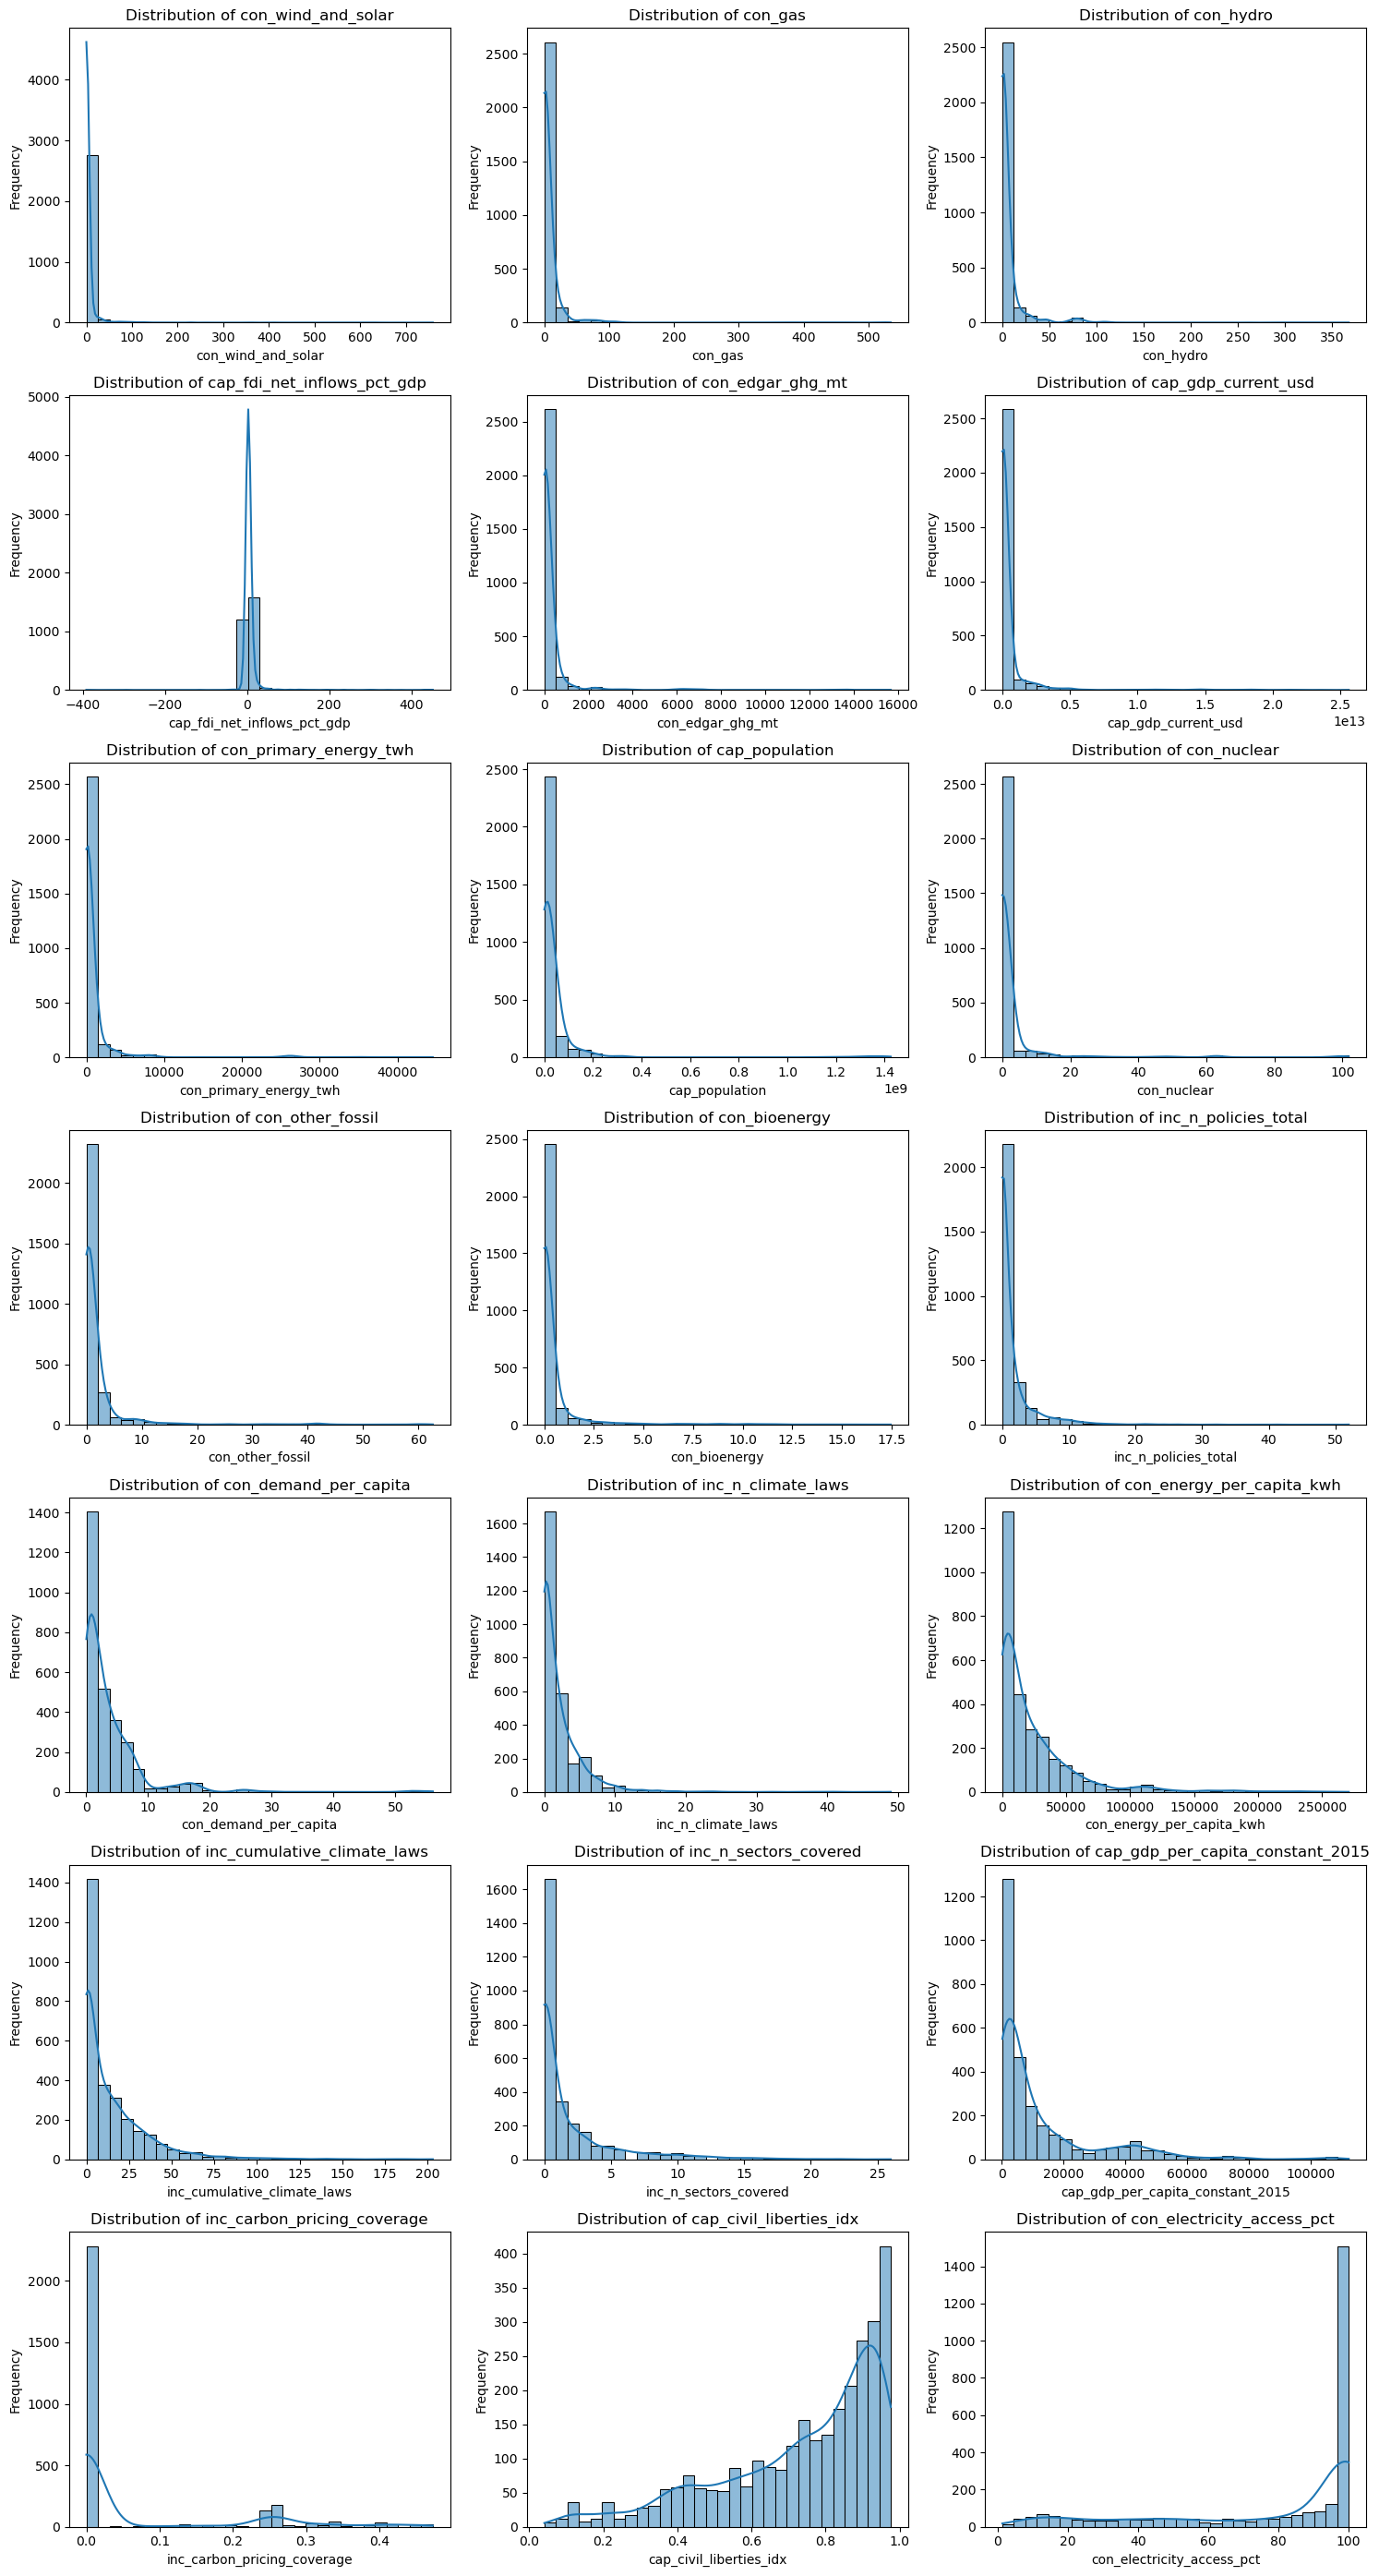

In [31]:
eda_utils.plot_numeric_fields_distributions(df_filtered[highly_skewed_fields])

In [32]:
# Log transform highly skewed fields
for field in highly_skewed_fields:
    df_filtered[f"x_log_signed_{field}"] = np.sign(df_filtered[field]) * np.log1p(np.abs(df_filtered[field]))
df_filtered.head()

,iso_alpha_3,year,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_population,cap_liberal_democracy_idx,cap_corruption_idx,cap_civil_liberties_idx,cap_govt_effectiveness,cap_political_stability,...,x_log_signed_inc_n_policies_total,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_inc_n_sectors_covered,x_log_signed_cap_gdp_per_capita_constant_2015,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,3.825701e+09,338.139974,21378117.0,0.084,0.919,0.523,-1.587687,-2.035034,...,0.0,0.039221,0.0,5.054301,0.0,0.0,5.826413,0.0,0.420682,2.714695
1,AFG,2003,4.520947e+09,346.071627,22733049.0,0.086,0.919,0.550,-1.175768,-2.198372,...,0.0,0.039221,0.0,5.167969,0.0,0.0,5.849531,0.0,0.438255,2.995732
2,AFG,2004,5.224897e+09,338.637274,23560654.0,0.091,0.931,0.546,-0.945146,-2.295682,...,0.0,0.039221,0.0,5.067381,0.0,0.0,5.827878,0.0,0.435671,3.210844
3,AFG,2005,6.203257e+09,363.640141,24404567.0,0.113,0.942,0.542,-1.228816,-2.067510,...,0.0,0.039221,0.0,5.330145,0.0,0.0,5.898911,0.0,0.433080,3.391147
4,AFG,2006,6.971758e+09,367.758312,25424094.0,0.199,0.955,0.540,-1.473652,-2.219135,...,0.0,0.048790,0.0,5.552444,0.0,0.0,5.910141,0.0,0.431782,3.540959


In [33]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 58 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   iso_alpha_3                                    2856 non-null   object 
 1   year                                           2856 non-null   int64  
 2   cap_gdp_current_usd                            2856 non-null   float64
 3   cap_gdp_per_capita_constant_2015               2856 non-null   float64
 4   cap_population                                 2856 non-null   float64
 5   cap_liberal_democracy_idx                      2856 non-null   float64
 6   cap_corruption_idx                             2856 non-null   float64
 7   cap_civil_liberties_idx                        2856 non-null   float64
 8   cap_govt_effectiveness                         2856 non-null   float64
 9   cap_political_stability                        2856 

In [34]:
# Drop the skewed fields since we have the log transform version
df_log_transformed = df_filtered.drop(columns=highly_skewed_fields)

In [35]:
skew_after_log_transform = df_log_transformed[[col for col in df_log_transformed.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew_after_log_transform.head(20)

x_log_signed_con_bioenergy                  3.204910
x_log_signed_con_wind_and_solar             2.861822
x_log_signed_con_nuclear                    2.769048
x_log_signed_con_other_fossil               1.994020
x_log_signed_inc_carbon_pricing_coverage    1.766301
x_log_signed_con_hydro                      1.589147
x_log_signed_con_gas                        1.486547
x_log_signed_inc_n_policies_total           1.402111
x_log_signed_inc_n_sectors_covered          1.126905
con_ndgain_readiness                        0.853076
con_forest_area_pct                         0.669409
x_log_signed_inc_n_climate_laws             0.635581
x_log_signed_con_demand_per_capita          0.535643
x_log_signed_con_edgar_ghg_mt               0.493132
cap_govt_effectiveness                      0.389971
x_log_signed_con_primary_energy_twh         0.379497
x_log_signed_cap_gdp_current_usd            0.365609
con_ndgain_vulnerability                    0.346669
cap_liberal_democracy_idx                   0.

In [36]:
zeros_and_variance_check_df_after_transformation = get_zeros_and_variance_check_df(df_log_transformed)
zeros_and_variance_check_df_after_transformation.head()

,field_name,field_zero_share,field_variance,bianry_flag
0,year,0.0,36.679510,False
1,cap_liberal_democracy_idx,0.0,0.069126,False
2,cap_corruption_idx,0.0,0.098262,False
3,cap_govt_effectiveness,0.0,0.950593,False
4,cap_political_stability,0.0,0.905499,False


In [37]:
# zeros_and_variance_check_df_after_transformation.to_clipboard()

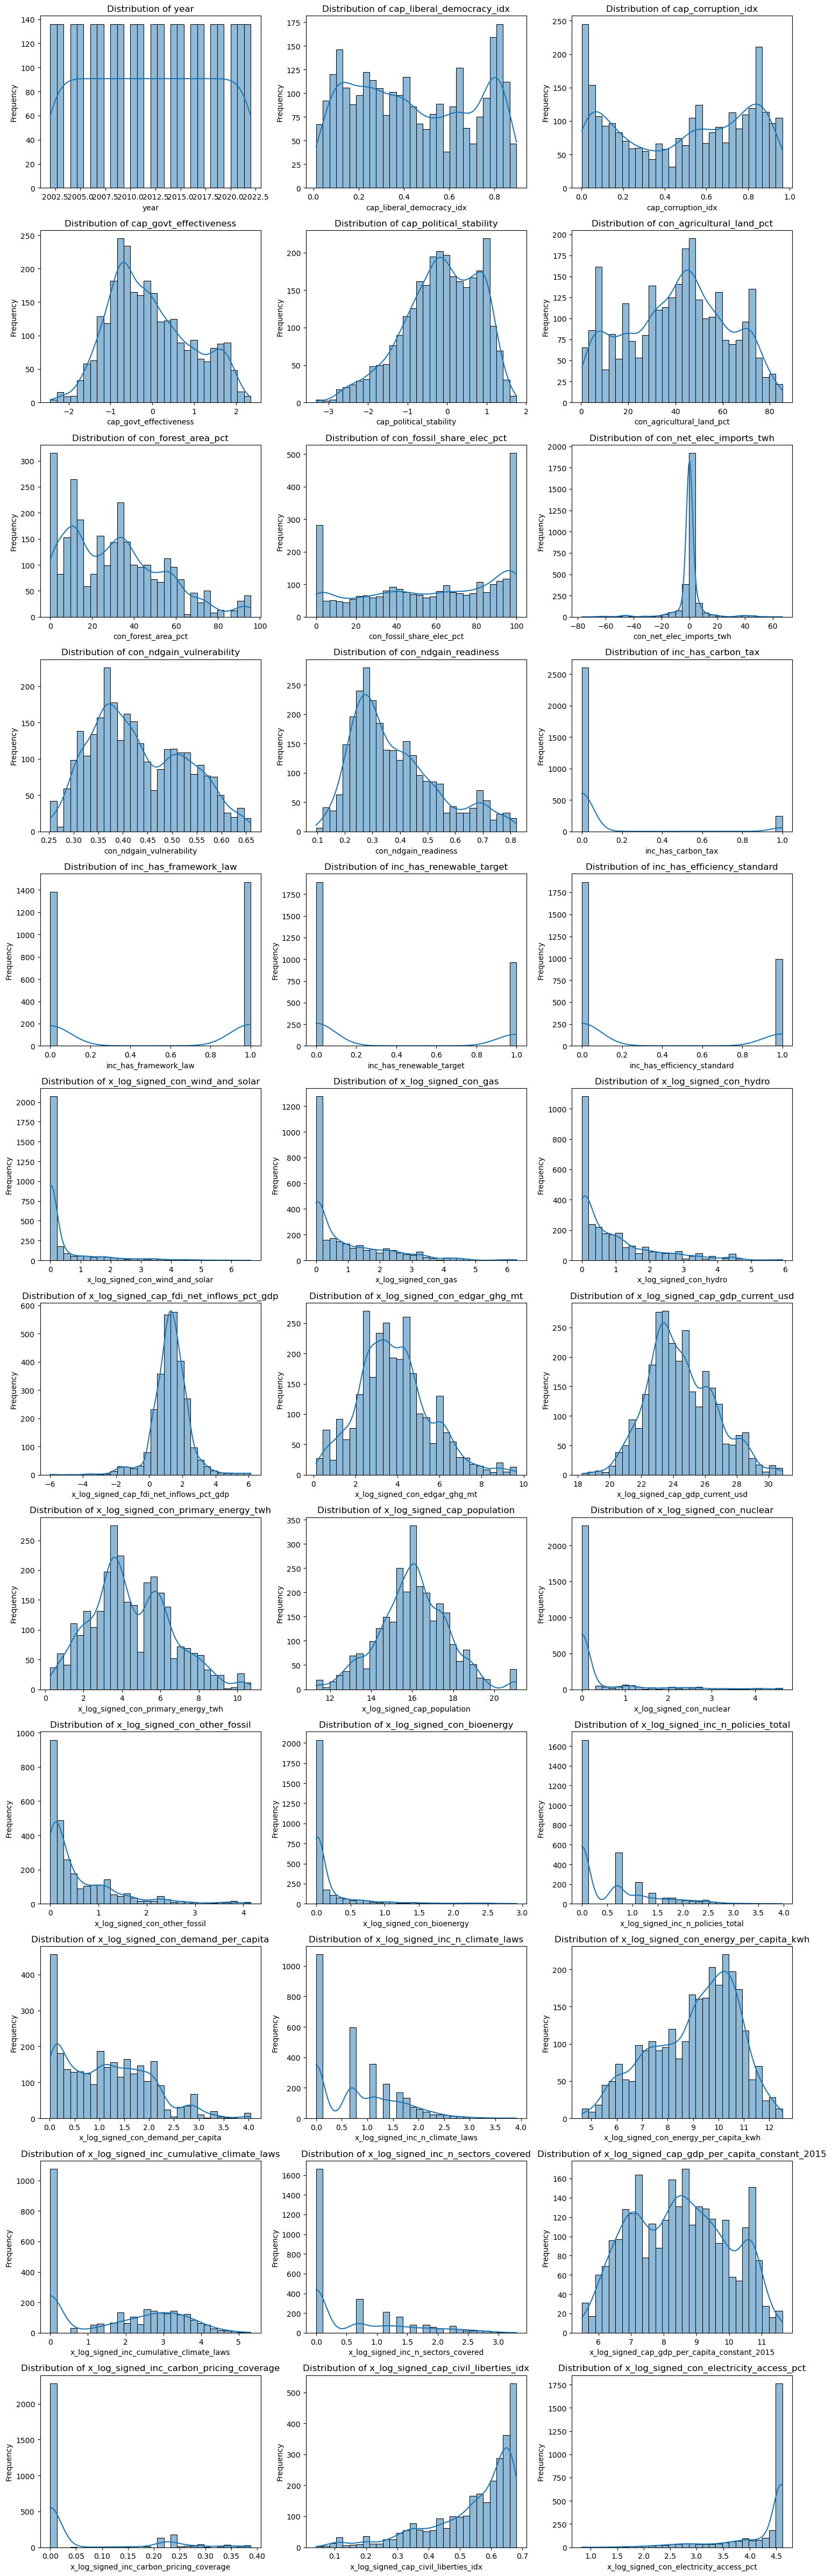

In [38]:
eda_utils.plot_numeric_fields_distributions(df_log_transformed)

In [39]:
df_log_transformed.columns

Index(['iso_alpha_3', 'year', 'cap_liberal_democracy_idx',
       'cap_corruption_idx', 'cap_govt_effectiveness',
       'cap_political_stability', 'con_agricultural_land_pct',
       'con_forest_area_pct', 'con_fossil_share_elec_pct',
       'con_net_elec_imports_twh', 'con_ndgain_vulnerability',
       'con_ndgain_readiness', 'inc_has_carbon_tax', 'inc_has_framework_law',
       'inc_has_renewable_target', 'inc_has_efficiency_standard',
       'x_log_signed_con_wind_and_solar', 'x_log_signed_con_gas',
       'x_log_signed_con_hydro', 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
       'x_log_signed_con_edgar_ghg_mt', 'x_log_signed_cap_gdp_current_usd',
       'x_log_signed_con_primary_energy_twh', 'x_log_signed_cap_population',
       'x_log_signed_con_nuclear', 'x_log_signed_con_other_fossil',
       'x_log_signed_con_bioenergy', 'x_log_signed_inc_n_policies_total',
       'x_log_signed_con_demand_per_capita', 'x_log_signed_inc_n_climate_laws',
       'x_log_signed_con_energy_per_cap

## ML

In [40]:
training_df = df_log_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
training_df.head()

,iso_alpha_3,year,cap_liberal_democracy_idx,cap_corruption_idx,cap_govt_effectiveness,cap_political_stability,con_agricultural_land_pct,con_forest_area_pct,con_fossil_share_elec_pct,con_net_elec_imports_twh,...,x_log_signed_inc_n_policies_total,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_inc_n_sectors_covered,x_log_signed_cap_gdp_per_capita_constant_2015,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,0.084,0.919,-1.587687,-2.035034,57.939684,1.852782,21.127,0.10,...,0.0,0.039221,0.0,5.054301,0.0,0.0,5.826413,0.0,0.420682,2.714695
1,AFG,2003,0.086,0.919,-1.175768,-2.198372,58.083805,1.852782,30.769,0.10,...,0.0,0.039221,0.0,5.167969,0.0,0.0,5.849531,0.0,0.438255,2.995732
2,AFG,2004,0.091,0.931,-0.945146,-2.295682,58.151266,1.852782,29.114,0.10,...,0.0,0.039221,0.0,5.067381,0.0,0.0,5.827878,0.0,0.435671,3.210844
3,AFG,2005,0.113,0.942,-1.228816,-2.067510,58.134400,1.852782,28.049,0.10,...,0.0,0.039221,0.0,5.330145,0.0,0.0,5.898911,0.0,0.433080,3.391147
4,AFG,2006,0.199,0.955,-1.473652,-2.219135,58.123668,1.852782,28.889,0.43,...,0.0,0.048790,0.0,5.552444,0.0,0.0,5.910141,0.0,0.431782,3.540959


In [41]:
training_df.year.max()

np.int64(2022)

In [42]:
target_var = "x_log_signed_con_edgar_ghg_mt"

In [43]:
features = [col for col in training_df.columns if col not in ["iso_alpha_3", "year", target_var]]
features

['cap_liberal_democracy_idx',
 'cap_corruption_idx',
 'cap_govt_effectiveness',
 'cap_political_stability',
 'con_agricultural_land_pct',
 'con_forest_area_pct',
 'con_fossil_share_elec_pct',
 'con_net_elec_imports_twh',
 'con_ndgain_vulnerability',
 'con_ndgain_readiness',
 'inc_has_carbon_tax',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard',
 'x_log_signed_con_wind_and_solar',
 'x_log_signed_con_gas',
 'x_log_signed_con_hydro',
 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
 'x_log_signed_cap_gdp_current_usd',
 'x_log_signed_con_primary_energy_twh',
 'x_log_signed_cap_population',
 'x_log_signed_con_nuclear',
 'x_log_signed_con_other_fossil',
 'x_log_signed_con_bioenergy',
 'x_log_signed_inc_n_policies_total',
 'x_log_signed_con_demand_per_capita',
 'x_log_signed_inc_n_climate_laws',
 'x_log_signed_con_energy_per_capita_kwh',
 'x_log_signed_inc_cumulative_climate_laws',
 'x_log_signed_inc_n_sectors_covered',
 'x_log_signed_cap_gdp_per_capita_const

In [44]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra = RegressionAnalysis(
    df=training_df,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    xgb_params=xgb_params,
    scaler_type="standard",
    feature_cols=features,
    include_year=False
)

ra.cross_validate()
ra.fit()
ra.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.3006          nan
RandomForest          0.3938       0.3719
XGBoost               0.3613       0.3590
Median                1.3262       1.3492

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.2662         0.2648            0.3424            0.3469               49.00               38.62
RandomForest            0.0171         0.1238            0.0313            0.1804                3.28               30.03
XGBoost                 0.0161         0.1281            0.0218            0.1761                4.06               52.02
Median                  1.3413         1.3160            1.7277            1.7185

{'ElasticNet': {'train_mae_log': 0.26620892749220726,
  'test_mae_log': 0.26476088751435345,
  'train_rmse_log': 0.3423737018919597,
  'test_rmse_log': 0.3468968169296404,
  'train_mae_level': np.float64(49.003141413824885),
  'test_mae_level': np.float64(38.622508352005916)},
 'RandomForest': {'train_mae_log': 0.01710060348789998,
  'test_mae_log': 0.1237524886171318,
  'train_rmse_log': 0.03126805549960894,
  'test_rmse_log': 0.18042957070776966,
  'train_mae_level': np.float64(3.2790291464816854),
  'test_mae_level': np.float64(30.032551721931014)},
 'XGBoost': {'train_mae_log': 0.01610287219423812,
  'test_mae_log': 0.1280916382997594,
  'train_rmse_log': 0.02179006275585814,
  'test_rmse_log': 0.17613825241073058,
  'train_mae_level': np.float64(4.06170310524755),
  'test_mae_level': np.float64(52.01932459245652)},
 'Median': {'train_mae_log': 1.3413164445990429,
  'test_mae_log': 1.3160106748006133,
  'train_rmse_log': 1.7277404471730828,
  'test_rmse_log': 1.7185362433467504,
  

In [45]:
country_erros_best_preds = ra.per_country_errors(model="ElasticNet")
country_erros_best_preds.sort_values(by="mae_level", ascending=False).head(10)

,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
66,USA,5,0.180864,0.183591,995.409415
26,IND,5,0.082232,0.085016,320.520517
1,CHN,5,0.018976,0.020884,286.106759
111,FRA,5,0.433847,0.437048,238.123117
29,RUS,5,0.088645,0.089308,217.793869
52,JPN,5,0.151647,0.153521,196.798194
101,ZAF,5,0.339889,0.343751,165.179739
108,BGD,5,0.420546,0.422742,145.424758
93,GBR,5,0.279742,0.280948,140.155032
40,BRA,5,0.111355,0.116288,135.851636


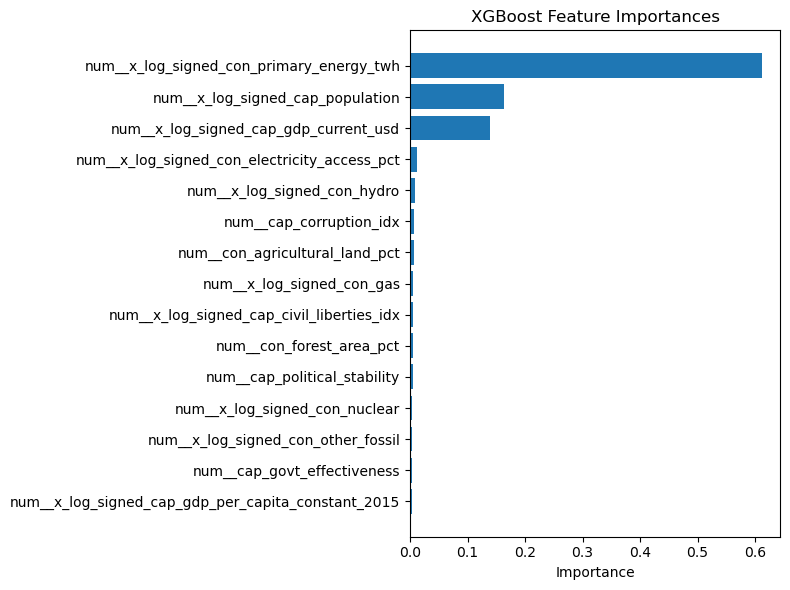

In [46]:
ra.plot_feature_importances(model="XGboost", top_n=15)

In [47]:
feature_names = ra.pipe_enet[:-1].get_feature_names_out()

coefs = ra.pipe_enet.named_steps["enet"].coef_

coef_table = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": abs(coefs)
    })
    .sort_values("abs_coef", ascending=False)
) 
coef_table.head()


,feature,coef,abs_coef
19,num__x_log_signed_con_primary_energy_twh,1.184499,1.184499
20,num__x_log_signed_cap_population,0.799079,0.799079
18,num__x_log_signed_cap_gdp_current_usd,0.437009,0.437009
25,num__x_log_signed_con_demand_per_capita,0.191691,0.191691
6,num__con_fossil_share_elec_pct,0.149234,0.149234


In [48]:
coef_table["type"] = coef_table["feature"].apply(lambda x: x.split("_")[0])
coef_table["clean_feature_name"] = coef_table["feature"].apply(lambda x: "_".join(x.split("_")[2:])) 
coef_table = coef_table[[
    "clean_feature_name",
    "coef",
    "abs_coef",
    "type"
]]
coef_table

,clean_feature_name,coef,abs_coef,type
19,x_log_signed_con_primary_energy_twh,1.184499,1.184499,num
20,x_log_signed_cap_population,0.799079,0.799079,num
18,x_log_signed_cap_gdp_current_usd,0.437009,0.437009,num
25,x_log_signed_con_demand_per_capita,0.191691,0.191691,num
6,con_fossil_share_elec_pct,0.149234,0.149234,num
...,...,...,...,...
69,iso_alpha_3_ESP,-0.000000,0.000000,cat
70,iso_alpha_3_EST,0.000000,0.000000,cat
71,iso_alpha_3_ETH,0.000000,0.000000,cat
72,iso_alpha_3_FIN,0.000000,0.000000,cat


In [49]:
coef_table.to_clipboard(index=False)

### Notes
- Performance gets worse when removing the highly correlated features.
- It's worth testing if a stricter correlation filter, e.g. > 0.95 and also using the model coefficients to check what to drop.
